# Diabetic Retinopathy Stage Detection (APTOS 2019)
**Module:** Computer Vision | **Model:** CNN transfer learning (EfficientNet-B3 / ResNet50) | **Framework:** PyTorch

Pipeline: 1 Setup, 2 Dataset, 3 Split, 4 Preprocessing, 5 Augmentation and balancing, 6 Experiments, 7 Model selection, 8 Test evaluation, 9 Error analysis and Grad-CAM, 10 Export for the web prototype.

**Before running:** Runtime > Change runtime type > **T4 GPU**. Set `DEBUG_QUICK_RUN = True` first for a few-minute smoke test, then set it back to `False` for the real run.

## 1. Setup and configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys, glob, json, time, random, tarfile, shutil
from concurrent.futures import ThreadPoolExecutor
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, cohen_kappa_score,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

# ---------------- CONFIGURATION (edit here only) ----------------
DEBUG_QUICK_RUN = False        # True = tiny smoke test (2 epochs per experiment)
PROJECT_DIR = '/content/drive/MyDrive/DR_Project_Data'   # dataset (csv + image folders) lives here
IMG_SIZE    = 300              # EfficientNet-B3 native resolution (use 256 if you run out of GPU memory)
BATCH_SIZE  = 24
SEED        = 42
PRETRAINED  = True             # ImageNet weights (keep True)
# -----------------------------------------------------------------

OUT_DIR = f"{PROJECT_DIR}/{'outputs_debug' if DEBUG_QUICK_RUN else 'outputs'}"
FIG_DIR = f'{OUT_DIR}/figures'
LOCAL_CACHE = f'/content/cache_{IMG_SIZE}'          # fast local disk for preprocessed images
CACHE_TAR   = f'{PROJECT_DIR}/cache_{IMG_SIZE}.tar' # backup on Drive so later sessions skip preprocessing
for d in (OUT_DIR, FIG_DIR, LOCAL_CACHE): os.makedirs(d, exist_ok=True)

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'                     # mixed precision = faster + less memory
sns.set_theme(style='whitegrid')
def savefig(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=200, bbox_inches='tight')
print('Device:', device, '| torch', torch.__version__)

Device: cuda | torch 2.11.0+cu128


### Shared module `dr_utils.py`
Preprocessing, model builders and Grad-CAM live in **one file** that is used by this notebook *and* by the web prototype, so inference uses exactly the same pipeline as training.

In [3]:
%%writefile /content/drive/MyDrive/DR_Project_Data/dr_utils.py
"""
dr_utils.py - shared code for the Diabetic Retinopathy project.

The SAME file is used by the training notebook and by the web prototype, so the
image preprocessing at inference time is identical to training (no train/serve skew).

Contents
  1. Preprocessing  : crop black borders -> pad to square -> resize -> CLAHE -> unsharp mask
  2. Models         : EfficientNet-B3 / ResNet50 with a new 5-class head (transfer learning)
  3. Grad-CAM       : heat-map showing which retinal regions drove the prediction
  4. Checkpoints    : save / load a self-describing checkpoint
"""
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms

CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # ImageNet statistics
EVAL_TF = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])


# --------------------------------------------------------------------------- #
# 1. PREPROCESSING  (all functions take / return RGB uint8 numpy arrays)
# --------------------------------------------------------------------------- #
def crop_black_borders(img, tol=7):
    """Remove the black background around the circular fundus region."""
    mask = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) > tol
    if not mask.any():                       # image too dark - return unchanged
        return img
    return img[mask.any(1)][:, mask.any(0)]


def pad_to_square(img):
    """Pad with black so resizing keeps the true aspect ratio (no distortion)."""
    h, w = img.shape[:2]
    s = max(h, w)
    out = np.zeros((s, s, 3), dtype=img.dtype)
    y, x = (s - h) // 2, (s - w) // 2
    out[y:y + h, x:x + w] = img
    return out


def apply_clahe(img, clip=2.0, tile=8):
    """Contrast Limited Adaptive Histogram Equalisation on the LAB lightness channel."""
    l, a, b = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2LAB))
    l = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)


def unsharp_mask(img, sigma=2.0, amount=0.5):
    """Edge enhancement: img + amount * (img - blurred). Sharpens vessels / lesions."""
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 1 + amount, blur, -amount, 0)


def ben_graham(img, sigma=10):
    """Local-average colour subtraction (Ben Graham, Kaggle DR 2015). Used for comparison only."""
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma), -4, 128)


def preprocess_fundus(img_rgb, size=300):
    """Full pipeline used for training AND inference."""
    img = crop_black_borders(img_rgb)
    img = pad_to_square(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    img = apply_clahe(img)
    return unsharp_mask(img)


# --------------------------------------------------------------------------- #
# 2. MODELS (transfer learning)
# --------------------------------------------------------------------------- #
def build_model(arch='efficientnet_b3', num_classes=5, pretrained=True):
    """ImageNet-pretrained backbone + new classification head."""
    if arch == 'efficientnet_b3':
        m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT if pretrained else None)
        m.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.classifier[1].in_features, num_classes))
    elif arch == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, num_classes))
    else:
        raise ValueError(f'Unknown architecture: {arch}')
    return m


def get_head(model, arch):
    return model.classifier if arch.startswith('efficientnet') else model.fc


def set_backbone_trainable(model, arch, trainable):
    """trainable=False -> only the new head learns (feature extraction).
       trainable=True  -> whole network learns (fine-tuning)."""
    head_ids = {id(p) for p in get_head(model, arch).parameters()}
    for p in model.parameters():
        p.requires_grad = True if trainable else (id(p) in head_ids)


# --------------------------------------------------------------------------- #
# 3. GRAD-CAM
# --------------------------------------------------------------------------- #
def _target_layer(model, arch):
    return model.features[-1] if arch.startswith('efficientnet') else model.layer4[-1]


def gradcam(model, arch, x, class_idx=None):
    """x: (1,3,H,W) tensor. Returns (cam in [0,1] at feature resolution, class index, softmax probs)."""
    model.eval()
    acts, grads = [], []

    def fwd_hook(_, __, out):
        acts.append(out)
        out.register_hook(lambda g: grads.append(g))

    handle = _target_layer(model, arch).register_forward_hook(fwd_hook)
    try:
        with torch.enable_grad():
            logits = model(x)
            idx = int(logits.argmax(1)) if class_idx is None else int(class_idx)
            model.zero_grad()
            logits[0, idx].backward()
    finally:
        handle.remove()
    weights = grads[0].mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * acts[0].detach()).sum(1))[0].cpu().numpy()
    cam = cam / (cam.max() + 1e-8)
    probs = torch.softmax(logits.detach()[0], 0).cpu().numpy()
    return cam, idx, probs


def overlay_cam(img_rgb, cam, alpha=0.45):
    """Blend a Grad-CAM map (jet colours) on top of an RGB uint8 image."""
    h, w = img_rgb.shape[:2]
    heat = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam, (w, h))), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_rgb, 1 - alpha, heat, alpha, 0)


# --------------------------------------------------------------------------- #
# 4. CHECKPOINTS
# --------------------------------------------------------------------------- #
def save_checkpoint(path, model, arch, img_size, extra=None):
    ck = {'arch': arch, 'img_size': int(img_size), 'class_names': CLASS_NAMES,
          'state_dict': {k: v.cpu() for k, v in model.state_dict().items()}}
    ck.update(extra or {})
    torch.save(ck, path)


def load_checkpoint(path, device='cpu'):
    ck = torch.load(path, map_location=device)
    model = build_model(ck['arch'], len(ck['class_names']), pretrained=False)
    model.load_state_dict(ck['state_dict'])
    return model.to(device).eval(), ck

Writing /content/drive/MyDrive/DR_Project_Data/dr_utils.py


In [4]:
sys.path.insert(0, PROJECT_DIR)
import importlib, dr_utils as U
importlib.reload(U)
CLASS_NAMES = U.CLASS_NAMES
print('Classes:', CLASS_NAMES)

Classes: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']


## 2. Problem understanding and dataset
**Diabetic retinopathy (DR)** damages the retinal blood vessels of people with diabetes and is a leading cause of preventable blindness. Early stages have no symptoms, so regular fundus screening matters, but grading photographs needs trained specialists who are scarce. An automated grader can help prioritise patients.

**Dataset:** APTOS 2019 Blindness Detection (Kaggle, `mariaherrerot/aptos2019`): fundus photographs graded 0-4 by clinicians (0 No DR, 1 Mild, 2 Moderate, 3 Severe, 4 Proliferative).

In [5]:
def find_csv(name):
    hits = glob.glob(f'{PROJECT_DIR}/**/{name}', recursive=True)
    return hits[0] if hits else None

frames = []
for name in ['train_1.csv', 'valid.csv', 'test.csv']:          # pool every labelled image, re-split ourselves
    p = find_csv(name)
    if p:
        frames.append(pd.read_csv(p)[['id_code', 'diagnosis']]); print('loaded', name, len(frames[-1]))
df = pd.concat(frames).drop_duplicates('id_code').reset_index(drop=True)

# index every raw image on Drive by its id (robust to folder layout)
img_index = {os.path.splitext(f)[0]: os.path.join(r, f)
             for r, _, fs in os.walk(PROJECT_DIR) if 'outputs' not in r
             for f in fs if f.lower().endswith(('.png', '.jpg', '.jpeg'))}
df['path'] = df['id_code'].map(img_index)
assert df['path'].notna().all(), f"{df['path'].isna().sum()} images missing on disk"
df['stage'] = df['diagnosis'].map(dict(enumerate(CLASS_NAMES)))
print('Total labelled images:', len(df))

loaded train_1.csv 2930
loaded valid.csv 366
loaded test.csv 366
Total labelled images: 3662


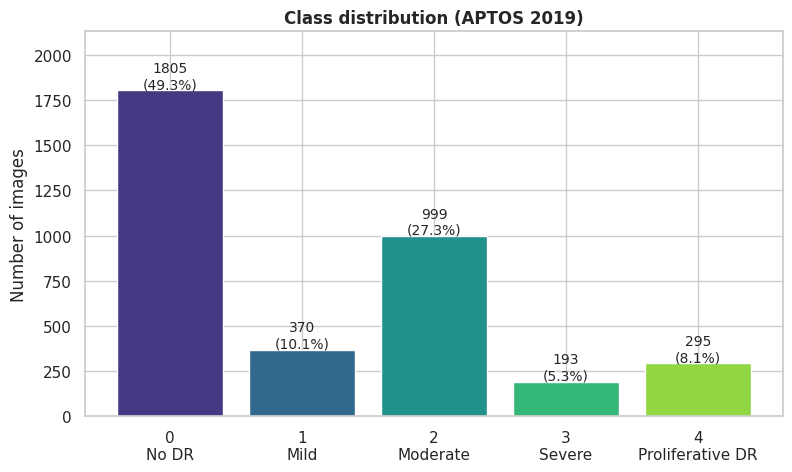

Imbalance ratio (largest/smallest class): 9.4x


In [6]:
counts = df['diagnosis'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([f'{i}\n{CLASS_NAMES[i]}' for i in counts.index], counts.values,
              color=sns.color_palette('viridis', 5))
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Class distribution (APTOS 2019)', fontweight='bold'); ax.set_ylabel('Number of images')
ax.set_ylim(0, counts.max()*1.18)
savefig('01_class_distribution'); plt.show()
print(f'Imbalance ratio (largest/smallest class): {counts.max()/counts.min():.1f}x')

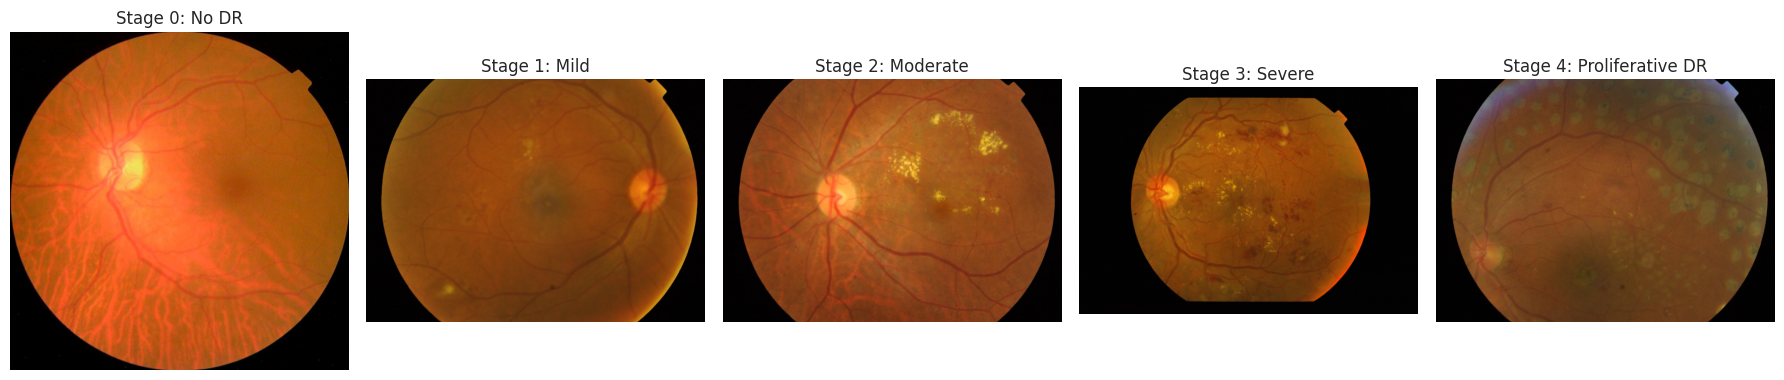

Distinct image resolutions in a 150-image sample: 13
(1050, 1050)    50
(2416, 1736)    34
(3216, 2136)    16
(2048, 1536)    14
(2588, 1958)    12
Name: count, dtype: int64


In [8]:
# one raw example per stage + image-size variability (dataset limitation: mixed resolutions / cameras)
fig, axs = plt.subplots(1, 5, figsize=(18, 4))
for c, ax in enumerate(axs):
    r = df[df.diagnosis == c].sample(1, random_state=SEED).iloc[0]
    ax.imshow(Image.open(r.path)); ax.set_title(f'Stage {c}: {CLASS_NAMES[c]}'); ax.axis('off')
plt.tight_layout(); savefig('02_raw_examples'); plt.show()

sizes = pd.Series([Image.open(p).size for p in df.path.sample(min(150, len(df)), random_state=SEED)])
print('Distinct image resolutions in a 150-image sample:', sizes.nunique())
print(sizes.value_counts().head(5))

## 3. Train / validation / test split
Stratified **70 / 15 / 15** split with a fixed seed. The test set is used **once**, at the very end. Models are compared and selected on the validation set only (using the test set for selection would leak information and inflate the reported score).

In [9]:
train_df, tmp_df = train_test_split(df, test_size=0.30, stratify=df.diagnosis, random_state=SEED)
val_df, test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df.diagnosis, random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]

split_table = pd.DataFrame({'Train': train_df.diagnosis.value_counts().sort_index(),
                            'Validation': val_df.diagnosis.value_counts().sort_index(),
                            'Test': test_df.diagnosis.value_counts().sort_index()})
split_table.index = CLASS_NAMES; split_table.loc['Total'] = split_table.sum()
display(split_table)
split_table.to_csv(f'{OUT_DIR}/split_table.csv')
for n, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    d[['id_code', 'diagnosis']].to_csv(f'{OUT_DIR}/split_{n}.csv', index=False)

,Train,Validation,Test
No DR,1263,271,271
Mild,259,55,56
Moderate,699,150,150
Severe,135,29,29
Proliferative DR,207,44,44
Total,2563,549,550


## 4. Image preprocessing
Pipeline (`U.preprocess_fundus`): **crop black borders -> pad to square -> resize -> CLAHE contrast enhancement (LAB lightness) -> unsharp-mask edge enhancement**.
The steps are per-image and use no dataset statistics, so they cannot leak information between splits.

In [10]:
def show_pipeline(ids):
    cols = ['Raw', '1. Crop + square', '2. + CLAHE (contrast)', '3. + Unsharp (edges) = FINAL', 'Ben Graham (alt.)', 'Canny edges of FINAL']
    fig, axs = plt.subplots(len(ids), 6, figsize=(20, 3.4*len(ids)))
    for r, i in enumerate(ids):
        raw = np.array(Image.open(img_index[i]).convert('RGB'))
        sq = cv2.resize(U.pad_to_square(U.crop_black_borders(raw)), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        cl = U.apply_clahe(sq); fin = U.unsharp_mask(cl)
        edges = cv2.Canny(cv2.cvtColor(fin, cv2.COLOR_RGB2GRAY), 40, 110)
        for c, im in enumerate([raw, sq, cl, fin, U.ben_graham(sq, IMG_SIZE/30), edges]):
            axs[r, c].imshow(im, cmap='gray' if im.ndim == 2 else None); axs[r, c].axis('off')
            if r == 0: axs[r, c].set_title(cols[c], fontsize=12)
    plt.tight_layout(); savefig('03_preprocessing_pipeline'); plt.show()

show_pipeline([df[df.diagnosis == c].id_code.iloc[0] for c in (0, 2, 4)])

Output hidden; open in https://colab.research.google.com to view.

Mean green-channel contrast (std) raw: 16.5  ->  preprocessed: 23.6


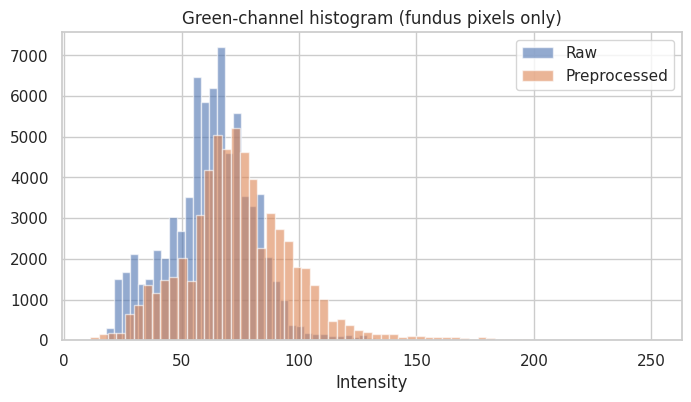

In [11]:
# Quantify the contrast gain: std-dev and histogram of the green channel (best vessel/lesion contrast)
sample_ids = df.id_code.sample(40, random_state=SEED).tolist()
before, after = [], []
for i in sample_ids:
    raw = np.array(Image.open(img_index[i]).convert('RGB')); fin = U.preprocess_fundus(raw, IMG_SIZE)
    small = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
    before.append(small[..., 1][small[..., 1] > 10].std()); after.append(fin[..., 1][fin[..., 1] > 10].std())
print(f'Mean green-channel contrast (std) raw: {np.mean(before):.1f}  ->  preprocessed: {np.mean(after):.1f}')

i = sample_ids[0]; raw = cv2.resize(np.array(Image.open(img_index[i]).convert('RGB')), (IMG_SIZE, IMG_SIZE))
fin = U.preprocess_fundus(np.array(Image.open(img_index[i]).convert('RGB')), IMG_SIZE)
plt.figure(figsize=(8, 4))
plt.hist(raw[..., 1][raw[..., 1] > 10].ravel(), 64, alpha=.6, label='Raw'); plt.hist(fin[..., 1][fin[..., 1] > 10].ravel(), 64, alpha=.6, label='Preprocessed')
plt.title('Green-channel histogram (fundus pixels only)'); plt.xlabel('Intensity'); plt.legend()
savefig('04_histogram_before_after'); plt.show()

In [12]:
# Preprocess ALL images once and cache them on fast local disk (also fixes the slow Google-Drive reads: ~6 min/epoch before).
def prep_one(args):
    i, path = args
    out = f'{LOCAL_CACHE}/{i}.png'
    if os.path.exists(out): return
    img = cv2.imread(path)
    if img is None: raise RuntimeError(f'Unreadable image: {path}')
    proc = U.preprocess_fundus(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), IMG_SIZE)
    cv2.imwrite(out, cv2.cvtColor(proc, cv2.COLOR_RGB2BGR))

if len(os.listdir(LOCAL_CACHE)) < len(df) and os.path.exists(CACHE_TAR):
    print('Restoring cache from Drive...'); tarfile.open(CACHE_TAR).extractall(LOCAL_CACHE)
todo = [(i, p) for i, p in zip(df.id_code, df.path) if not os.path.exists(f'{LOCAL_CACHE}/{i}.png')]
if todo:
    print(f'Preprocessing {len(todo)} images...')
    with ThreadPoolExecutor(8) as ex: list(tqdm(ex.map(prep_one, todo), total=len(todo)))
    with tarfile.open(CACHE_TAR, 'w') as tf:
        for f in os.listdir(LOCAL_CACHE): tf.add(f'{LOCAL_CACHE}/{f}', arcname=f)
print('Cached images:', len(os.listdir(LOCAL_CACHE)))

Preprocessing 3662 images...


  0%|          | 0/3662 [00:00<?, ?it/s]

Cached images: 3662


## 5. Data augmentation and class balancing
* **Augmentation (training only):** flips, rotation (+-25 deg), small shift/zoom, brightness/contrast jitter. Fundus images have no fixed orientation and cameras vary in exposure, so these are label-preserving. Validation/test images are never augmented.
* **Imbalance** (Stage 0 dominates, Stage 3 is rare): two strategies are compared as experiments: (a) **class-weighted loss**, (b) **balanced oversampling** with `WeightedRandomSampler`.
* Class weights are computed from the **training split only**.

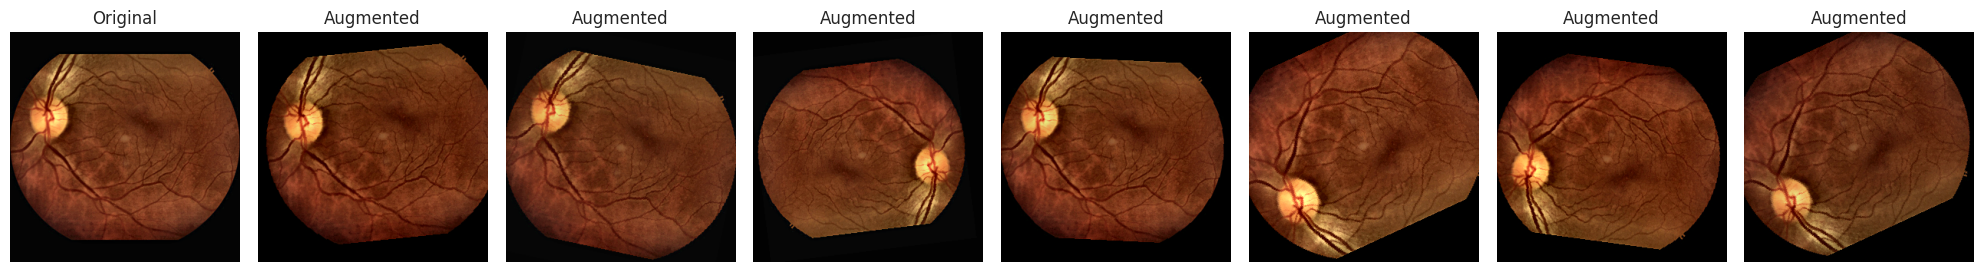

In [13]:
aug_only = transforms.Compose([
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=25, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)])
train_tf = transforms.Compose([aug_only, transforms.ToTensor(), transforms.Normalize(U.MEAN, U.STD)])
eval_tf = U.EVAL_TF

class DRDataset(Dataset):
    """Loads the pre-processed (cached) image; augmentation is applied on-the-fly for training only."""
    def __init__(self, frame, transform):
        self.ids, self.labels, self.transform = frame.id_code.values, frame.diagnosis.values, transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, k):
        img = Image.open(f'{LOCAL_CACHE}/{self.ids[k]}.png').convert('RGB')
        return self.transform(img), int(self.labels[k])

# augmentation gallery: one image, 7 random augmentations
base = Image.open(f'{LOCAL_CACHE}/{train_df.id_code[0]}.png').convert('RGB')
fig, axs = plt.subplots(1, 8, figsize=(20, 3))
axs[0].imshow(base); axs[0].set_title('Original');
for a in axs[1:]: a.imshow(aug_only(base)); a.set_title('Augmented')
for a in axs: a.axis('off')
plt.tight_layout(); savefig('05_augmentation_examples'); plt.show()

Class weights (train split): {'No DR': np.float64(0.406), 'Mild': np.float64(1.979), 'Moderate': np.float64(0.733), 'Severe': np.float64(3.797), 'Proliferative DR': np.float64(2.476)}


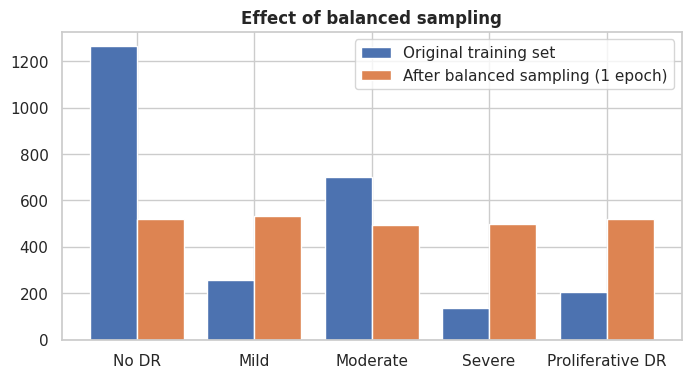

In [14]:
class_w = compute_class_weight('balanced', classes=np.arange(5), y=train_df.diagnosis.values)
class_w_t = torch.tensor(class_w, dtype=torch.float32)
print('Class weights (train split):', dict(zip(CLASS_NAMES, class_w.round(3))))

def make_train_loader(balance):
    kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True, persistent_workers=True, drop_last=True)
    ds = DRDataset(train_df, train_tf)
    if balance == 'sampler':
        cnt = np.bincount(train_df.diagnosis, minlength=5)
        sw = 1.0 / cnt[train_df.diagnosis.values]
        return DataLoader(ds, sampler=WeightedRandomSampler(sw, len(ds), replacement=True), **kw)
    return DataLoader(ds, shuffle=True, **kw)

val_loader  = DataLoader(DRDataset(val_df,  eval_tf), batch_size=BATCH_SIZE, num_workers=2)
test_loader = DataLoader(DRDataset(test_df, eval_tf), batch_size=BATCH_SIZE, num_workers=2)

# evidence that balanced sampling works: label counts seen in one epoch
cnt = np.bincount(train_df.diagnosis, minlength=5); sw = 1.0 / cnt[train_df.diagnosis.values]
drawn = np.bincount(train_df.diagnosis.values[list(WeightedRandomSampler(sw, len(train_df), replacement=True))], minlength=5)
fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(5)
ax.bar(x - .2, cnt, .4, label='Original training set'); ax.bar(x + .2, drawn, .4, label='After balanced sampling (1 epoch)')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES); ax.legend(); ax.set_title('Effect of balanced sampling', fontweight='bold')
savefig('06_balancing_effect'); plt.show()

## 6. Experiments (transfer learning + training strategy)
Four controlled experiments; each changes **one thing** relative to another so the effect can be discussed in the report:

| ID | Backbone | Strategy | Imbalance handling |
|---|---|---|---|
| E1 | EfficientNet-B3 | Feature extraction (backbone frozen) | class-weighted loss |
| E2 | EfficientNet-B3 | Head warm-up, then **fine-tune all layers** | class-weighted loss |
| E3 | EfficientNet-B3 | Same as E2 | **balanced sampler** |
| E4 | ResNet50 | Same as E2 | class-weighted loss |

Training tools: AdamW, `ReduceLROnPlateau` learning-rate schedule, dropout 0.4 in the head, weight decay, augmentation, mixed precision, **early stopping** and best-checkpoint saving on **validation macro-F1**. Every run uses the same seed and the same split.

In [15]:
EXPERIMENTS = [
    dict(name='E1_b3_frozen',        arch='efficientnet_b3', finetune=False, epochs=15, warmup_epochs=0, lr_head=1e-3, lr_ft=None, balance='weights', patience=6),
    dict(name='E2_b3_finetune',      arch='efficientnet_b3', finetune=True,  epochs=25, warmup_epochs=3, lr_head=1e-3, lr_ft=1e-4, balance='weights', patience=6),
    dict(name='E3_b3_finetune_samp', arch='efficientnet_b3', finetune=True,  epochs=25, warmup_epochs=3, lr_head=1e-3, lr_ft=1e-4, balance='sampler', patience=6),
    dict(name='E4_resnet50_finetune',arch='resnet50',        finetune=True,  epochs=25, warmup_epochs=3, lr_head=1e-3, lr_ft=1e-4, balance='weights', patience=6),
]
if DEBUG_QUICK_RUN:
    EXPERIMENTS = [{**c, 'epochs': 2, 'warmup_epochs': min(c['warmup_epochs'], 1), 'patience': 2} for c in EXPERIMENTS]
display(pd.DataFrame(EXPERIMENTS).set_index('name'))

,arch,finetune,epochs,warmup_epochs,lr_head,lr_ft,balance,patience
name,,,,,,,,
E1_b3_frozen,efficientnet_b3,False,15,0,0.001,NaN,weights,6
E2_b3_finetune,efficientnet_b3,True,25,3,0.001,0.0001,weights,6
E3_b3_finetune_samp,efficientnet_b3,True,25,3,0.001,0.0001,sampler,6
E4_resnet50_finetune,resnet50,True,25,3,0.001,0.0001,weights,6


In [17]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Returns loss (if criterion given), labels, predictions and class probabilities."""
    model.eval(); tot, n, Y, P, PR = 0.0, 0, [], [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            out = model(x)
        out = out.float()
        if criterion is not None: tot += criterion(out, y).item() * x.size(0)
        n += x.size(0); Y.append(y.cpu().numpy()); P.append(out.argmax(1).cpu().numpy()); PR.append(torch.softmax(out, 1).cpu().numpy())
    return dict(loss=tot / n if criterion is not None else None, y=np.concatenate(Y), pred=np.concatenate(P), prob=np.concatenate(PR))

def scores(r):
    return dict(acc=float((r['y'] == r['pred']).mean()),
                f1=float(f1_score(r['y'], r['pred'], average='macro', zero_division=0)),
                qwk=float(cohen_kappa_score(r['y'], r['pred'], weights='quadratic')))

def run_experiment(cfg):
    name, arch = cfg['name'], cfg['arch']
    print(f"\n{'='*70}\n{name}: {cfg}\n{'='*70}")
    set_seed()
    model = U.build_model(arch, 5, pretrained=PRETRAINED).to(device).to(memory_format=torch.channels_last)
    train_loader = make_train_loader(cfg['balance'])
    criterion = nn.CrossEntropyLoss(weight=class_w_t.to(device) if cfg['balance'] == 'weights' else None)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    def new_opt(lr):
        o = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
        return o, torch.optim.lr_scheduler.ReduceLROnPlateau(o, mode='min', factor=0.5, patience=2)

    U.set_backbone_trainable(model, arch, False)          # start with only the new head learning
    opt, sched = new_opt(cfg['lr_head'])
    H = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_f1', 'val_qwk', 'epoch_time']}
    best_f1, best_epoch, bad, t0 = -1, 0, 0, time.time()
    ckpt_path = f"{OUT_DIR}/ckpt_{name}.pth"

    for epoch in range(cfg['epochs']):
        if cfg['finetune'] and epoch == cfg['warmup_epochs']:      # phase 2: unfreeze everything, lower LR
            U.set_backbone_trainable(model, arch, True); opt, sched = new_opt(cfg['lr_ft']); bad = 0
            print('  >> backbone unfrozen (fine-tuning all layers)')
        t = time.time(); model.train(); tl, tc, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True).contiguous(memory_format=torch.channels_last), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
                out = model(x)
            loss = criterion(out.float(), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item() * x.size(0); tc += (out.argmax(1) == y).sum().item(); n += x.size(0)
        r = evaluate(model, val_loader, criterion); s = scores(r); sched.step(r['loss'])
        for k, v in zip(H, [tl / n, r['loss'], tc / n, s['acc'], s['f1'], s['qwk'], time.time() - t]): H[k].append(float(v))
        star = ''
        if s['f1'] > best_f1:
            best_f1, best_epoch, bad, star = s['f1'], epoch + 1, 0, '  <- best'
            U.save_checkpoint(ckpt_path, model, arch, IMG_SIZE, extra={'val_f1': best_f1, 'name': name})
        else: bad += 1
        print(f"  Ep {epoch+1:02d}/{cfg['epochs']} [{H['epoch_time'][-1]:.0f}s] loss {tl/n:.3f}/{r['loss']:.3f}  acc {tc/n:.3f}/{s['acc']:.3f}  valF1 {s['f1']:.3f}  QWK {s['qwk']:.3f}{star}")
        if bad >= cfg['patience']: print(f'  Early stopping (no val-F1 gain for {bad} epochs)'); break

    b = best_epoch - 1
    H.update(name=name, cfg=cfg, best_epoch=best_epoch, best_val_f1=H['val_f1'][b], best_val_acc=H['val_acc'][b],
             best_val_qwk=H['val_qwk'][b], minutes=(time.time() - t0) / 60, epochs_run=len(H['val_f1']))
    json.dump(H, open(f'{OUT_DIR}/hist_{name}.json', 'w'))
    del model, opt; torch.cuda.empty_cache()
    return H

In [18]:
# Runs every experiment. Finished ones are loaded from Drive, so if Colab disconnects just re-run this cell.
results = {}
for cfg in EXPERIMENTS:
    hp = f"{OUT_DIR}/hist_{cfg['name']}.json"
    if os.path.exists(hp): results[cfg['name']] = json.load(open(hp)); print('Loaded finished run:', cfg['name'])
    else: results[cfg['name']] = run_experiment(cfg)


E1_b3_frozen: {'name': 'E1_b3_frozen', 'arch': 'efficientnet_b3', 'finetune': False, 'epochs': 15, 'warmup_epochs': 0, 'lr_head': 0.001, 'lr_ft': None, 'balance': 'weights', 'patience': 6}
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 210MB/s]


  Ep 01/15 [47s] loss 1.424/1.232  acc 0.515/0.701  valF1 0.508  QWK 0.797  <- best
  Ep 02/15 [25s] loss 1.223/1.143  acc 0.646/0.661  valF1 0.498  QWK 0.740
  Ep 03/15 [24s] loss 1.128/1.110  acc 0.655/0.681  valF1 0.514  QWK 0.746  <- best
  Ep 04/15 [25s] loss 1.104/1.080  acc 0.655/0.719  valF1 0.548  QWK 0.809  <- best
  Ep 05/15 [25s] loss 1.087/1.080  acc 0.659/0.719  valF1 0.535  QWK 0.804
  Ep 06/15 [24s] loss 1.056/1.078  acc 0.657/0.758  valF1 0.567  QWK 0.818  <- best
  Ep 07/15 [24s] loss 1.035/1.061  acc 0.686/0.734  valF1 0.549  QWK 0.815
  Ep 08/15 [25s] loss 1.017/1.037  acc 0.678/0.679  valF1 0.516  QWK 0.819
  Ep 09/15 [23s] loss 1.002/1.036  acc 0.675/0.681  valF1 0.518  QWK 0.811
  Ep 10/15 [25s] loss 1.007/1.010  acc 0.675/0.685  valF1 0.523  QWK 0.818
  Ep 11/15 [25s] loss 0.996/1.038  acc 0.688/0.714  valF1 0.531  QWK 0.808
  Ep 12/15 [23s] loss 1.009/1.015  acc 0.686/0.698  valF1 0.545  QWK 0.824
  Early stopping (no val-F1 gain for 6 epochs)

E2_b3_finetune: 

100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


  Ep 01/25 [25s] loss 1.426/1.308  acc 0.541/0.658  valF1 0.434  QWK 0.722  <- best
  Ep 02/25 [24s] loss 1.208/1.198  acc 0.664/0.718  valF1 0.496  QWK 0.791  <- best
  Ep 03/25 [23s] loss 1.137/1.142  acc 0.670/0.685  valF1 0.514  QWK 0.769  <- best
  >> backbone unfrozen (fine-tuning all layers)
  Ep 04/25 [28s] loss 0.945/0.981  acc 0.717/0.659  valF1 0.500  QWK 0.807
  Ep 05/25 [26s] loss 0.826/0.931  acc 0.750/0.709  valF1 0.540  QWK 0.816  <- best
  Ep 06/25 [28s] loss 0.739/0.808  acc 0.788/0.772  valF1 0.640  QWK 0.872  <- best
  Ep 07/25 [29s] loss 0.691/0.839  acc 0.801/0.729  valF1 0.585  QWK 0.858
  Ep 08/25 [25s] loss 0.620/0.904  acc 0.811/0.727  valF1 0.559  QWK 0.873
  Ep 09/25 [27s] loss 0.577/0.819  acc 0.828/0.756  valF1 0.624  QWK 0.879
  Ep 10/25 [27s] loss 0.523/0.817  acc 0.845/0.783  valF1 0.651  QWK 0.876  <- best
  Ep 11/25 [29s] loss 0.457/0.894  acc 0.866/0.787  valF1 0.647  QWK 0.880
  Ep 12/25 [27s] loss 0.384/0.901  acc 0.878/0.791  valF1 0.652  QWK 0.87

## 7. Compare experiments and select the best model (on validation data)

,Backbone,Strategy,Imbalance,Epochs run,Best epoch,Val accuracy,Val macro-F1,Val QWK,Minutes
Experiment,,,,,,,,,
E1_b3_frozen,efficientnet_b3,frozen,weights,12,6,0.7577,0.5675,0.8178,5.3
E2_b3_finetune,efficientnet_b3,fine-tune,weights,12,6,0.8179,0.6943,0.8892,6.1
E3_b3_finetune_samp,efficientnet_b3,fine-tune,sampler,20,14,0.8270,0.6897,0.9034,10.2
E4_resnet50_finetune,resnet50,fine-tune,weights,23,17,0.7942,0.6680,0.8859,10.2



Selected on VALIDATION macro-F1 -> E2_b3_finetune


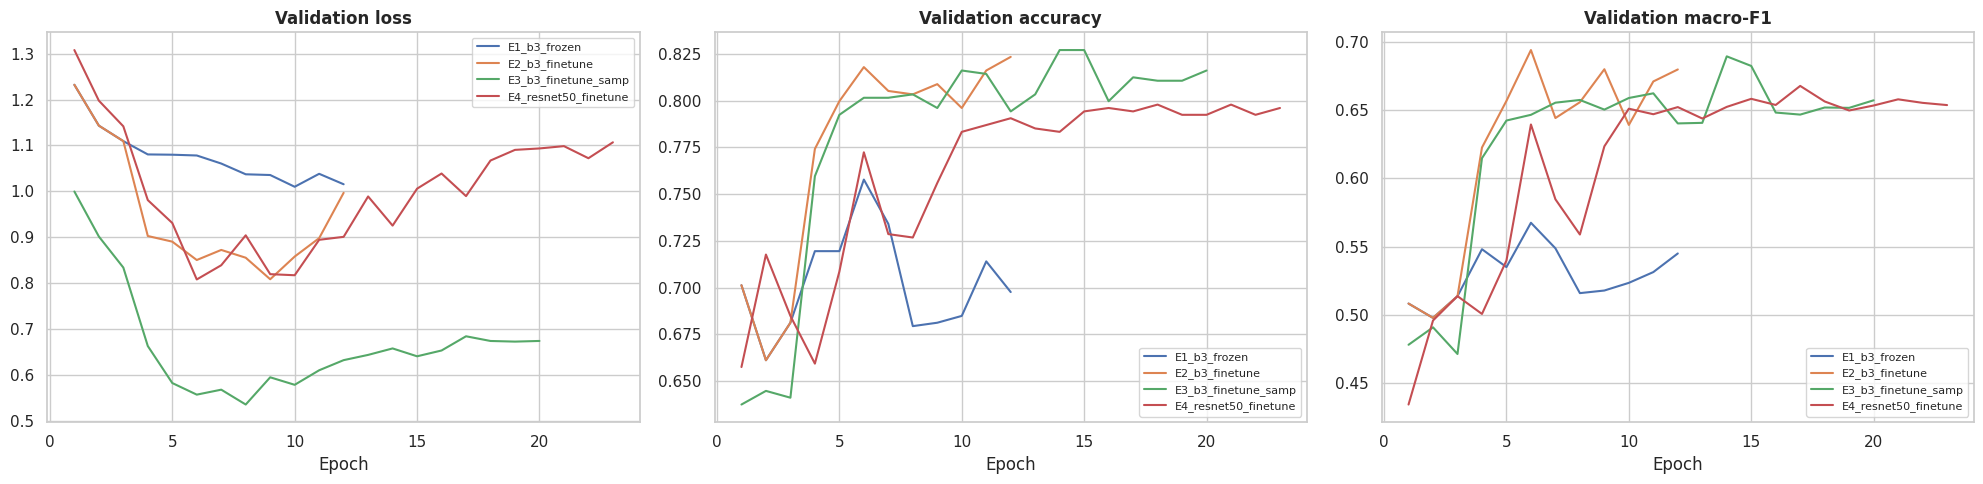

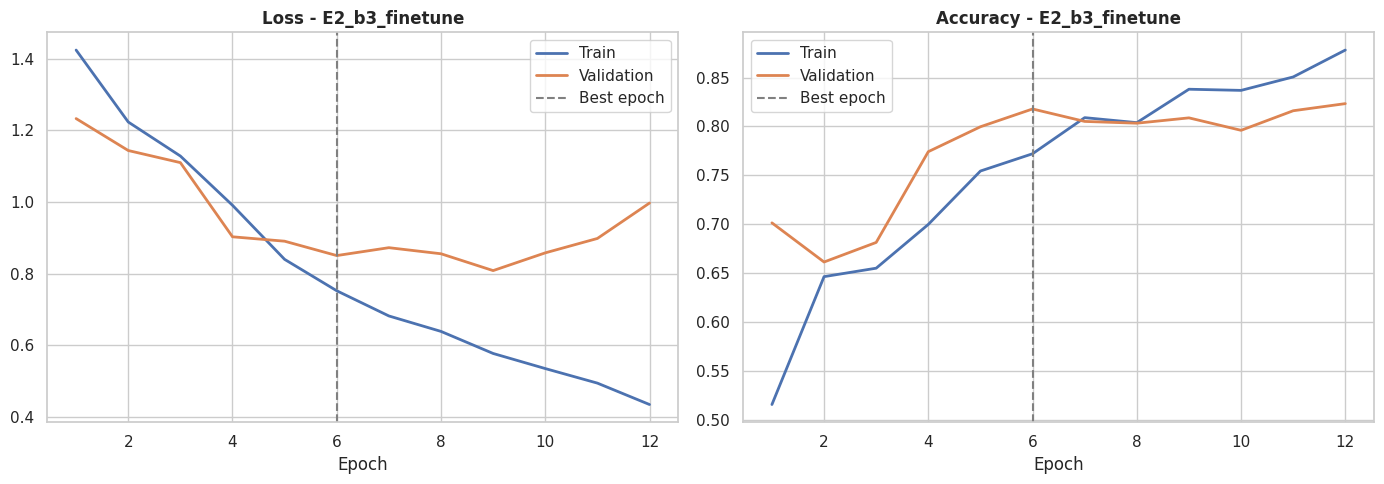

In [19]:
summary = pd.DataFrame([{ 'Experiment': k, 'Backbone': v['cfg']['arch'], 'Strategy': 'fine-tune' if v['cfg']['finetune'] else 'frozen',
    'Imbalance': v['cfg']['balance'], 'Epochs run': v['epochs_run'], 'Best epoch': v['best_epoch'],
    'Val accuracy': round(v['best_val_acc'], 4), 'Val macro-F1': round(v['best_val_f1'], 4),
    'Val QWK': round(v['best_val_qwk'], 4), 'Minutes': round(v['minutes'], 1)} for k, v in results.items()]).set_index('Experiment')
display(summary); summary.to_csv(f'{OUT_DIR}/experiment_summary.csv')
best_name = summary['Val macro-F1'].idxmax()
print(f'\nSelected on VALIDATION macro-F1 -> {best_name}')

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for k, v in results.items():
    e = range(1, len(v['val_loss']) + 1)
    axs[0].plot(e, v['val_loss'], label=k); axs[1].plot(e, v['val_acc'], label=k); axs[2].plot(e, v['val_f1'], label=k)
for a, t in zip(axs, ['Validation loss', 'Validation accuracy', 'Validation macro-F1']):
    a.set_title(t, fontweight='bold'); a.set_xlabel('Epoch'); a.legend(fontsize=8)
plt.tight_layout(); savefig('07_experiment_comparison'); plt.show()

# accuracy / loss curves of the SELECTED model (train vs validation) - required by the brief
v = results[best_name]; e = range(1, len(v['val_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(e, v['train_loss'], label='Train', lw=2); axs[0].plot(e, v['val_loss'], label='Validation', lw=2); axs[0].set_title(f'Loss - {best_name}', fontweight='bold')
axs[1].plot(e, v['train_acc'], label='Train', lw=2); axs[1].plot(e, v['val_acc'], label='Validation', lw=2); axs[1].set_title(f'Accuracy - {best_name}', fontweight='bold')
for a in axs: a.axvline(v['best_epoch'], ls='--', c='grey', label='Best epoch'); a.set_xlabel('Epoch'); a.legend()
plt.tight_layout(); savefig('08_best_model_curves'); plt.show()

## 8. Final evaluation on the held-out test set
The selected model is evaluated on the test set **once**. Metrics: accuracy, precision, recall, F1 (per class, macro, weighted), confusion matrix, quadratic weighted kappa (the official APTOS metric, which penalises large staging errors more) and one-vs-rest ROC-AUC.

In [20]:
model, ck = U.load_checkpoint(f'{OUT_DIR}/ckpt_{best_name}.pth', device)
ARCH = ck['arch']
res = evaluate(model, test_loader)
y, pred, prob = res['y'], res['pred'], res['prob']
sc = scores(res)
print(f"TEST accuracy {sc['acc']:.4f} | macro-F1 {sc['f1']:.4f} | QWK {sc['qwk']:.4f}\n")
print(classification_report(y, pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
rep = classification_report(y, pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
pd.DataFrame(rep).T.round(3).to_csv(f'{OUT_DIR}/test_classification_report.csv')
try: auc = roc_auc_score(label_binarize(y, classes=range(5)), prob, average='macro', multi_class='ovr'); print(f'Macro one-vs-rest ROC-AUC: {auc:.4f}')
except ValueError: auc = None

TEST accuracy 0.8236 | macro-F1 0.6684 | QWK 0.8875

                  precision    recall  f1-score   support

           No DR      0.964     0.982     0.973       271
            Mild      0.600     0.750     0.667        56
        Moderate      0.790     0.753     0.771       150
          Severe      0.407     0.379     0.393        29
Proliferative DR      0.618     0.477     0.538        44

        accuracy                          0.824       550
       macro avg      0.676     0.668     0.668       550
    weighted avg      0.822     0.824     0.821       550

Macro one-vs-rest ROC-AUC: 0.9441


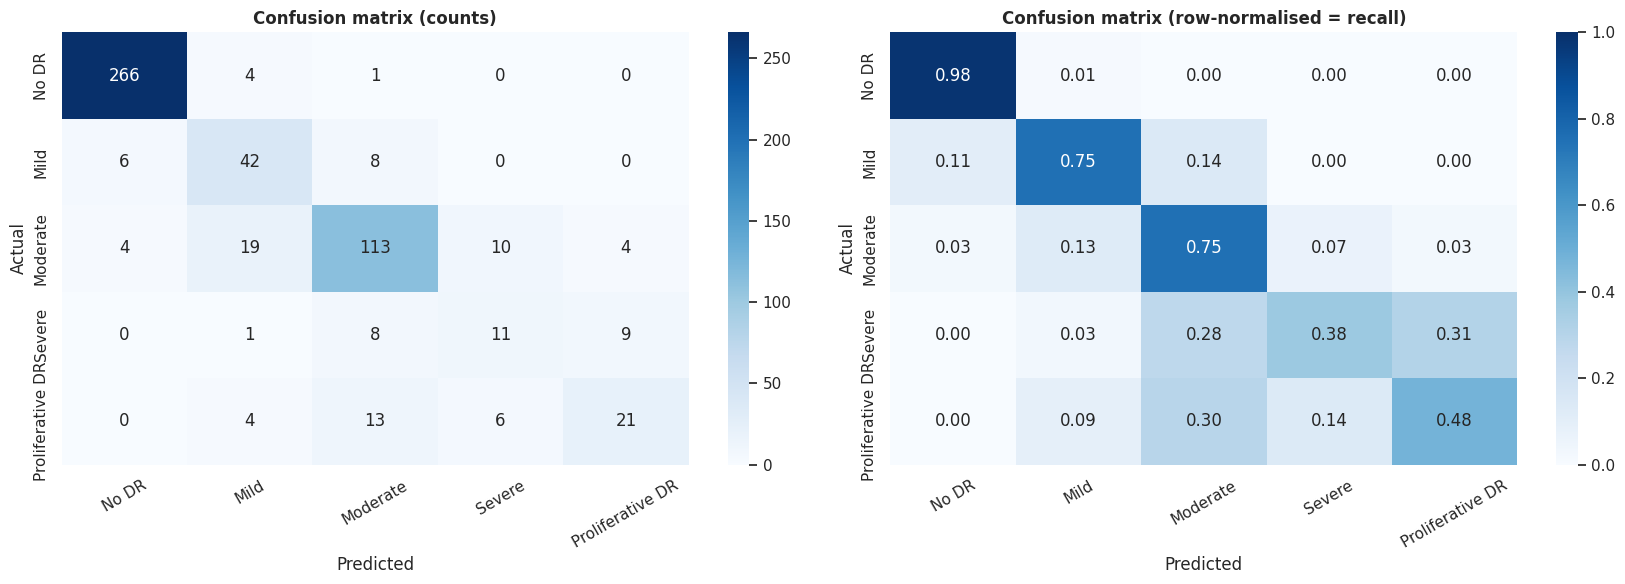

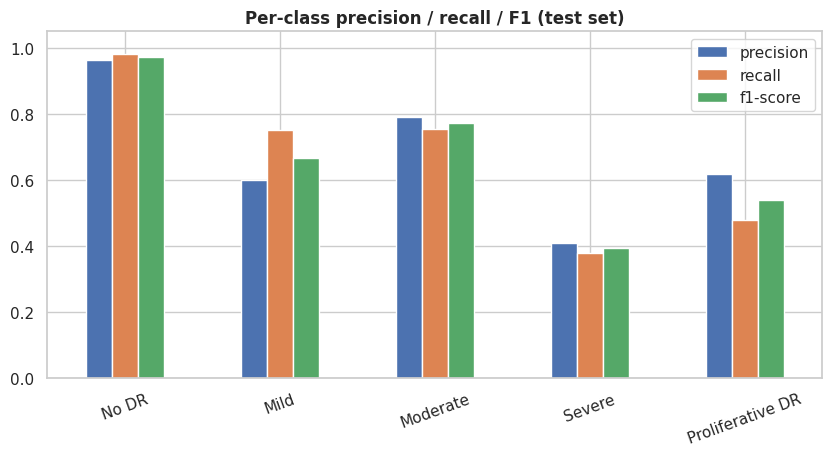

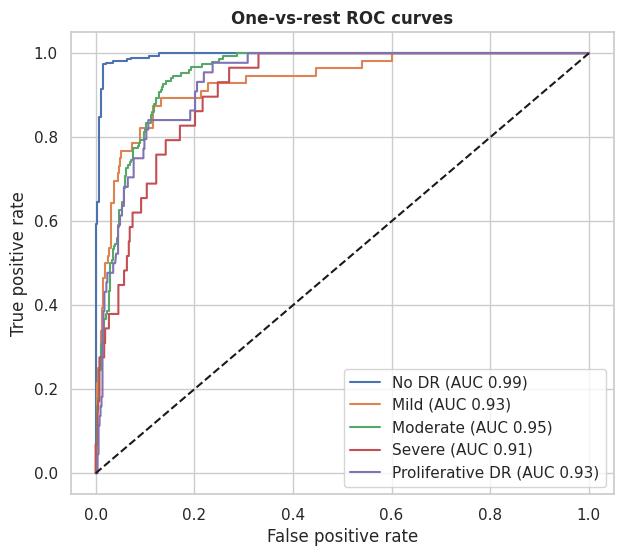

In [21]:
cm = confusion_matrix(y, pred, labels=range(5)); cmn = cm / cm.sum(1, keepdims=True).clip(1)
fig, axs = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axs[0]); axs[0].set_title('Confusion matrix (counts)', fontweight='bold')
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axs[1], vmin=0, vmax=1); axs[1].set_title('Confusion matrix (row-normalised = recall)', fontweight='bold')
for a in axs: a.set_xlabel('Predicted'); a.set_ylabel('Actual'); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); savefig('09_confusion_matrix'); plt.show()

m = pd.DataFrame(rep).T.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score']]
m.plot.bar(figsize=(10, 4.5), rot=20, ylim=(0, 1.05)); plt.title('Per-class precision / recall / F1 (test set)', fontweight='bold')
savefig('10_per_class_metrics'); plt.show()

plt.figure(figsize=(7, 6)); Yb = label_binarize(y, classes=range(5))
for c in range(5):
    if Yb[:, c].sum() == 0: continue
    fpr, tpr, _ = roc_curve(Yb[:, c], prob[:, c]); plt.plot(fpr, tpr, label=f'{CLASS_NAMES[c]} (AUC {roc_auc_score(Yb[:, c], prob[:, c]):.2f})')
plt.plot([0, 1], [0, 1], 'k--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.legend(); plt.title('One-vs-rest ROC curves', fontweight='bold')
savefig('11_roc_curves'); plt.show()

In [22]:
# Save the deployable model (weights + architecture + test scores) for the web prototype
ck['test_accuracy'], ck['test_kappa'], ck['test_macro_f1'] = sc['acc'], sc['qwk'], sc['f1']
torch.save(ck, f'{OUT_DIR}/best_dr_model.pth')
json.dump({'selected': best_name, 'test': sc, 'auc': auc}, open(f'{OUT_DIR}/test_metrics.json', 'w'), indent=2)
print('Saved:', f'{OUT_DIR}/best_dr_model.pth')

Saved: /content/drive/MyDrive/DR_Project_Data/outputs/best_dr_model.pth


## 9. Error analysis and explainability (Grad-CAM)

97 errors out of 550; 70 (72%) are only one stage away from the true stage.
Under-grading (missed severity): 61 | Over-grading: 36


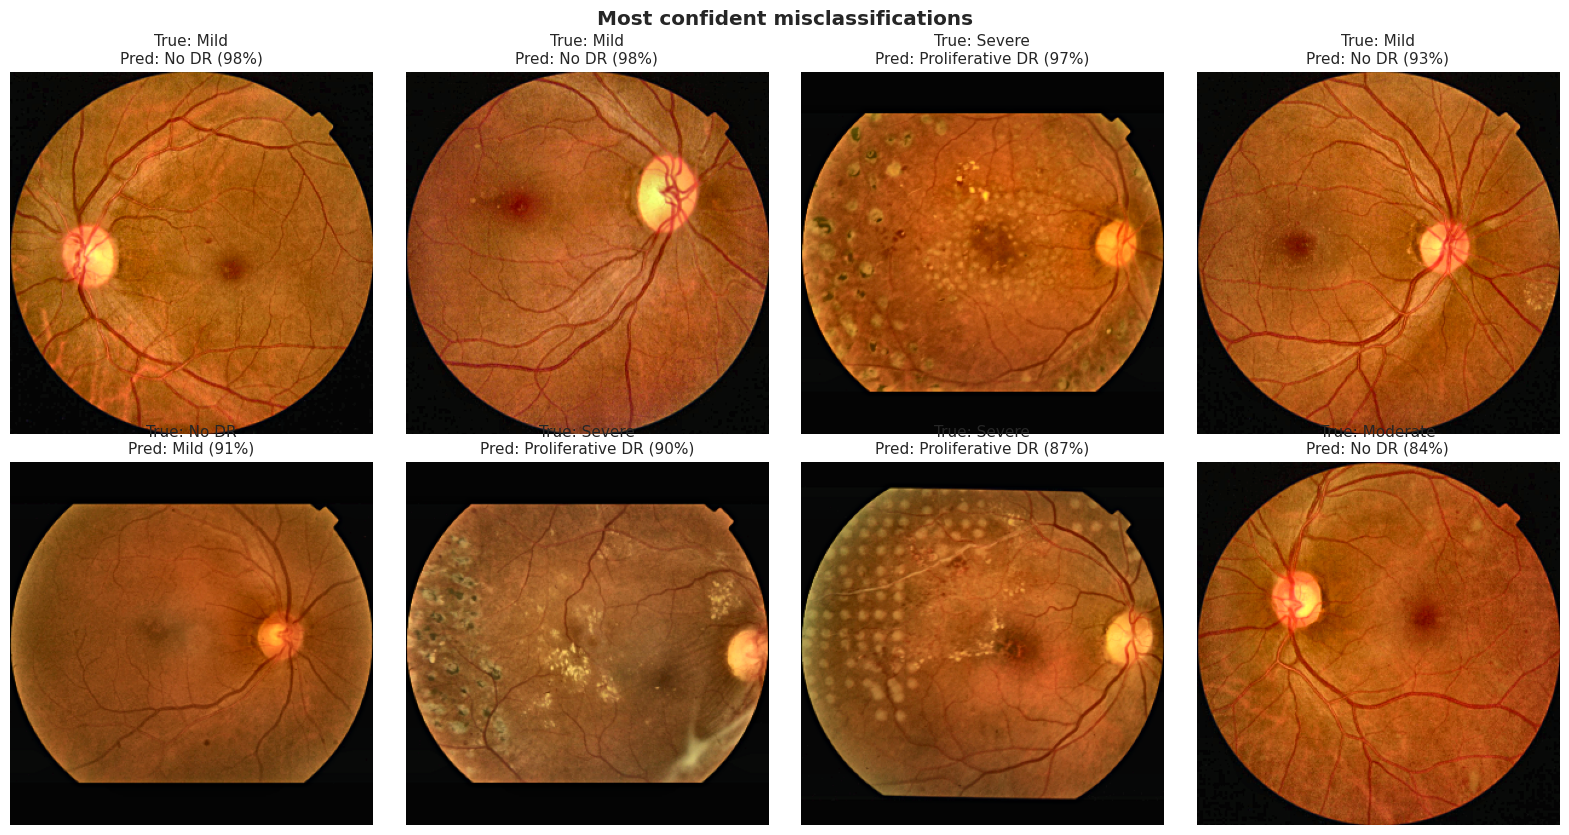

In [23]:
errs = np.where(pred != y)[0]; off1 = np.sum(np.abs(pred[errs] - y[errs]) == 1)
print(f'{len(errs)} errors out of {len(y)}; {off1} ({off1/max(len(errs),1)*100:.0f}%) are only one stage away from the true stage.')
under = np.sum(pred[errs] < y[errs]); print(f'Under-grading (missed severity): {under} | Over-grading: {len(errs)-under}')

def cached(idx): return np.array(Image.open(f'{LOCAL_CACHE}/{test_df.id_code[idx]}.png').convert('RGB'))

# most confident mistakes
worst = errs[np.argsort(-prob[errs].max(1))][:8]
fig, axs = plt.subplots(2, 4, figsize=(16, 8.5))
for a, i in zip(axs.ravel(), worst):
    a.imshow(cached(i)); a.set_title(f'True: {CLASS_NAMES[y[i]]}\nPred: {CLASS_NAMES[pred[i]]} ({prob[i].max()*100:.0f}%)', fontsize=11); a.axis('off')
plt.suptitle('Most confident misclassifications', fontweight='bold'); plt.tight_layout(); savefig('12_misclassified'); plt.show()

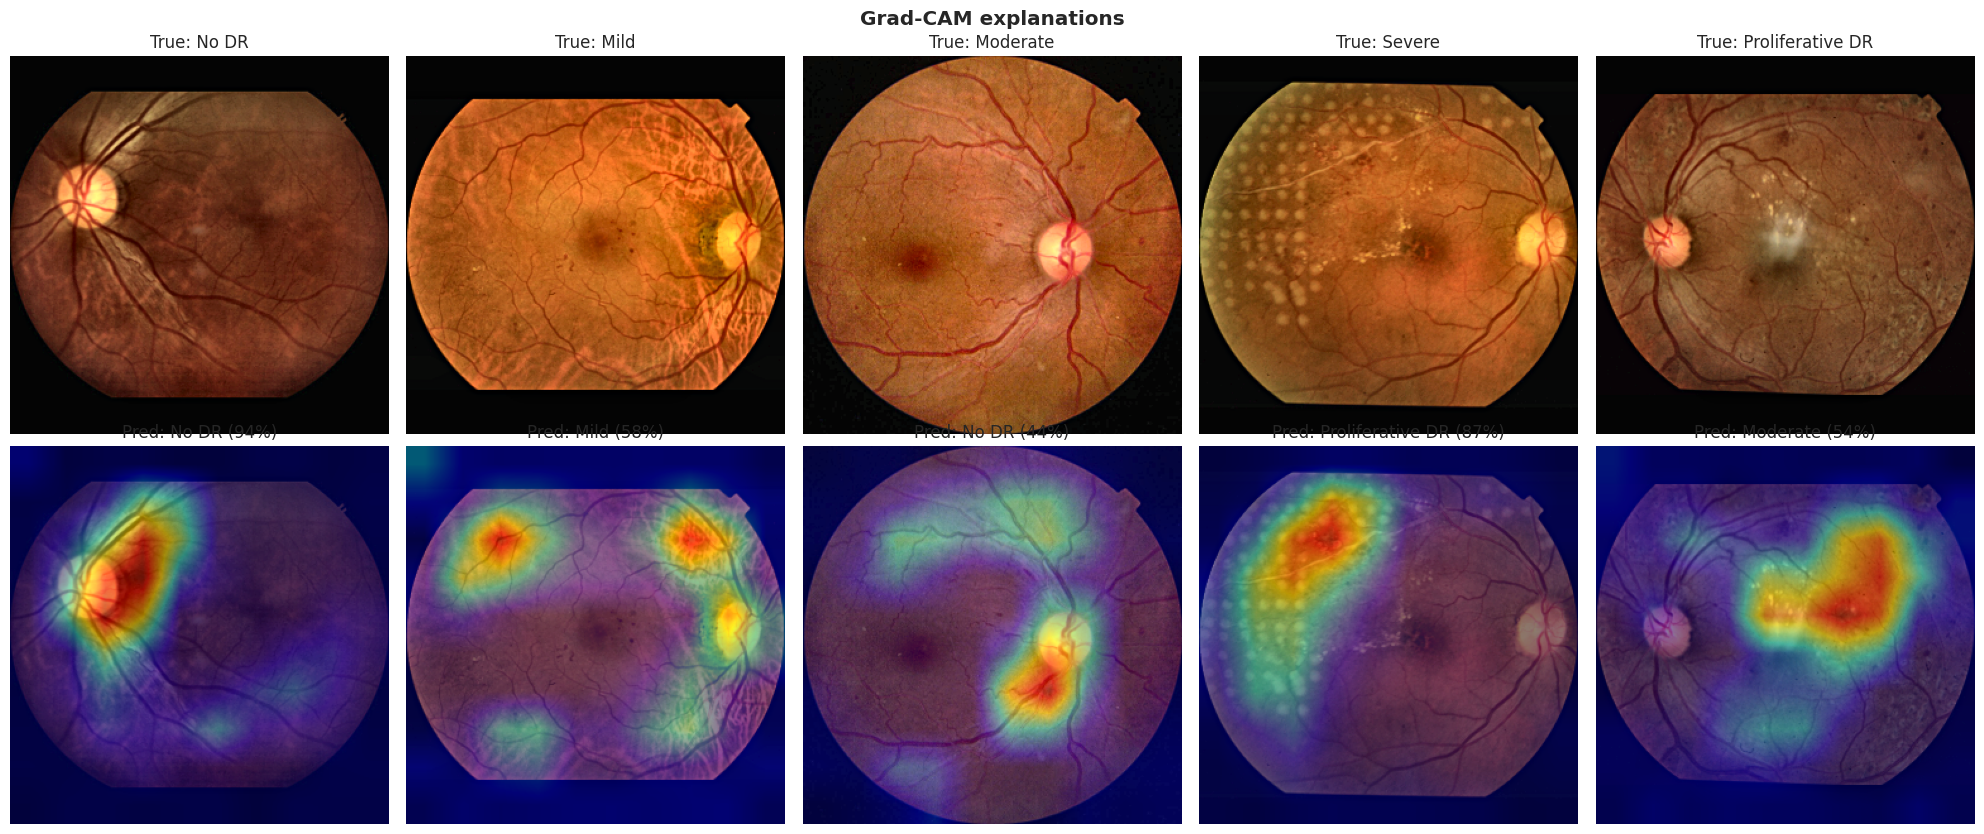

In [24]:
# Grad-CAM: one test image per stage (heat = regions that pushed the model toward its prediction)
fig, axs = plt.subplots(2, 5, figsize=(20, 8.5))
for c in range(5):
    idx = np.where(y == c)[0]
    if len(idx) == 0: continue
    i = idx[0]; img = cached(i)
    cam, k, p = U.gradcam(model, ARCH, U.EVAL_TF(img).unsqueeze(0).to(device))
    axs[0, c].imshow(img); axs[0, c].set_title(f'True: {CLASS_NAMES[c]}'); axs[1, c].imshow(U.overlay_cam(img, cam)); axs[1, c].set_title(f'Pred: {CLASS_NAMES[k]} ({p[k]*100:.0f}%)')
    axs[0, c].axis('off'); axs[1, c].axis('off')
plt.suptitle('Grad-CAM explanations', fontweight='bold'); plt.tight_layout(); savefig('13_gradcam'); plt.show()

## 10. Export for the prototype and report
Download **`best_dr_model.pth`** and **`dr_utils.py`** from `DR_Project_Data/outputs` / `DR_Project_Data` in Google Drive and place them beside `app.py`.

In [25]:
shutil.make_archive('/content/report_figures', 'zip', FIG_DIR)
print('Figures zip:', '/content/report_figures.zip')
print(f"\nKEY NUMBERS FOR THE REPORT\n  Selected model : {best_name}\n  Test accuracy  : {sc['acc']:.4f}\n  Test macro-F1  : {sc['f1']:.4f}\n  Test QWK       : {sc['qwk']:.4f}")
try:
    from google.colab import files; files.download('/content/report_figures.zip')
except Exception: pass

Figures zip: /content/report_figures.zip

KEY NUMBERS FOR THE REPORT
  Selected model : E2_b3_finetune
  Test accuracy  : 0.8236
  Test macro-F1  : 0.6684
  Test QWK       : 0.8875


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>